In [53]:
%load_ext autoreload
%autoreload 2
from wc import simulate_wc_w_dist, find_fixed_points, merge_fixed_points
import jax.numpy as jnp
import jax
import seaborn as sns
key = jax.random.PRNGKey(0)
plane_size = 80.0
num_E, num_I = 40, 10
N = num_E + num_I

key_pos, key_w, key = jax.random.split(key, 3)
pos_init = jax.random.uniform(key_pos, (N, 2), minval=0, maxval=plane_size)   # only build this once

init_neurons = jnp.concatenate([0.35 * jnp.ones(num_E), 0.15 * jnp.ones(num_I)])
is_exc = jnp.concatenate([jnp.ones(num_E, dtype=bool), jnp.zeros(num_I, dtype=bool)])

w_EE, w_EI, w_IE, w_II = 1.6, 2.8, 1.6, 2.8  
exc_target = is_exc[:, None]
exc_source = is_exc[None, :]

magnitude = jnp.where(exc_source,
                       jnp.where(exc_target, w_EE, w_IE),
                       jnp.where(exc_target, w_EI, w_II))
sign = jnp.where(exc_source, 1.0, -1.0)

jitter = 1.0 + 0.2 * jax.random.normal(key_w, (N, N))   # +/-20%ish per-connection variation
base_weight_matrix = magnitude * sign * jitter

I_ext = jnp.ones(N)
dt = 0.5
range_t = jnp.arange(0, 100, dt)
a_dist = 1 / (0.3 * plane_size)
a_sigmoid = 1.2
theta = 3.5
tau_E = 1.0
tau_I = 0.5

r_trace = simulate_wc_w_dist(
    init_state=init_neurons, pos_init=pos_init, is_exc=is_exc, I_ext=I_ext,
    range_t=range_t, a_dist=a_dist, a_sigmoid=a_sigmoid, W=base_weight_matrix,
    dt=dt, tau_I=tau_I, tau_E=tau_E, theta=theta,
)

rE_trace = r_trace[:, :num_E]
rI_trace = r_trace[:, num_E:]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Axes: >

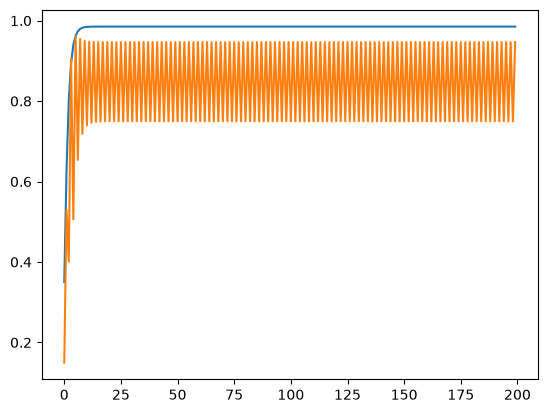

In [28]:
sns.lineplot(rE_trace[:,3])
sns.lineplot(rI_trace[:,9])

Parameters I plan to vary:
1. W_IE, W_EI, WEE, W_EI, Iext


In [89]:
params = {
    "exc_map": is_exc,
    "2dmap": pos_init,
    "ext_input": I_ext,
    "distance_decay": a_dist,
    "sigmoid_steepness": a_sigmoid,
    "theta": theta,
    "weights": base_weight_matrix,
    "tau_I": tau_I,
    "tau_E": tau_E,
}
fixed_points = find_fixed_points(params, steps=25, num_samples=30)



In [90]:
from wc import jacobian_at

all_fixed_points_clean = merge_fixed_points(fixed_points)
for i in range(len(all_fixed_points_clean)):
    J = jacobian_at(all_fixed_points_clean[i], params)
    eigenvals, eigenvecs = jnp.linalg.eig(J)
    print("eigenvals: ", eigenvals)



eigenvals:  [-2.0003595 +0.j -1.9997737 +0.j -1.9999108 +0.j -1.9999695 +0.j
 -2.0000043 +0.j -0.9991632 +0.j -1.9999877 +0.j -1.9999958 +0.j
 -1.9999986 +0.j -1.9999999 +0.j -2.0000005 +0.j -1.000522  +0.j
 -1.0002968 +0.j -1.0000242 +0.j -0.99997586+0.j -0.99998397+0.j
 -1.0000111 +0.j -0.9999917 +0.j -1.000013  +0.j -0.99999934+0.j
 -1.000006  +0.j -1.0000063 +0.j -1.0000046 +0.j -1.0000006 +0.j
 -0.9999999 +0.j -1.0000002 +0.j -1.0000013 +0.j -1.0000032 +0.j
 -1.0000026 +0.j -1.000002  +0.j -1.0000015 +0.j -1.0000002 +0.j
 -0.9999997 +0.j -1.0000007 +0.j -1.0000015 +0.j -1.0000005 +0.j
 -1.000001  +0.j -1.        +0.j -0.99999994+0.j -1.0000001 +0.j
 -0.99999994+0.j -0.9999996 +0.j -1.0000001 +0.j -1.0000001 +0.j
 -1.0000002 +0.j -1.0000001 +0.j -0.99999964+0.j -1.0000006 +0.j
 -1.        +0.j -0.9999999 +0.j]


In [102]:
# old code for tracking aggregate eigvalue metrics for all fixed points in single tuple
# def get_local_behavior(params):
#     fixed_points = find_fixed_points(params, steps=25, num_samples=30)
#     all_fixed_points_clean = merge_fixed_points(fixed_points)
#     max_real_parts = []
#     max_complex_coeff = []

#     for i in range(len(all_fixed_points_clean)):
#         J = jacobian_at(all_fixed_points_clean[i], params)
#         eigenvals, eigenvectors = jnp.linalg.eig(J)
#         max_real_parts.append(jnp.max(eigenvals.real))
#         max_complex_coeff.append(jnp.max(jnp.abs(eigenvals.imag)))
#     return jnp.max(jnp.array(max_real_parts)), jnp.max(jnp.array(max_complex_coeff)), all_fixed_points_clean

from scipy.optimize import linear_sum_assignment

# tracks eigvalue metrics for each fixed point independently, detects bifurcations and emerging new fixed points
def get_local_behavior(params):
    fixed_points = find_fixed_points(params, steps=25, num_samples=30)
    all_fixed_points_clean = merge_fixed_points(fixed_points)
    max_real_parts = []
    max_complex_coeff = []

    for i in range(len(all_fixed_points_clean)):
        J = jacobian_at(all_fixed_points_clean[i], params)
        eigenvals, eigenvectors = jnp.linalg.eig(J)
        max_real_parts.append(float(jnp.max(eigenvals.real)))
        max_complex_coeff.append(float(jnp.max(jnp.abs(eigenvals.imag))))

    agg_real = jnp.max(jnp.array(max_real_parts)) if max_real_parts else float('nan')
    agg_imag = jnp.max(jnp.array(max_complex_coeff)) if max_complex_coeff else float('nan')
    return agg_real, agg_imag, all_fixed_points_clean, max_real_parts, max_complex_coeff




In [103]:
#sweep ranges
wI_range = jnp.linspace(0.8, 18, 25)
wE_range = jnp.linspace(0.5, 5, 10)     
extI_range = jnp.linspace(0, 6, 5)    
extE_range = jnp.linspace(0, 6, 5)
wI_sweep_tracker = []
i = 0
for wI in wI_range:
    print(f"starting {i}")
    exc_target = is_exc[:, None]
    exc_source = is_exc[None, :]

    magnitude = jnp.where(exc_source,
                        jnp.where(exc_target, w_EE, w_IE),
                        jnp.where(exc_target, wI, wI))
    sign = jnp.where(exc_source, 1.0, -1.0)
    weight_matrix = magnitude * sign * jitter

    params = {
        "exc_map": is_exc,
        "2dmap": pos_init,
        "ext_input": I_ext,
        "distance_decay": a_dist,
        "sigmoid_steepness": a_sigmoid,
        "theta": theta,
        "weights": weight_matrix,
        "tau_I": tau_I,
        "tau_E": tau_E,
    }
    
    wI_sweep_tracker.append(get_local_behavior(params)[0:5])
    i+=1




starting 0
starting 1
starting 2
starting 3
starting 4
starting 5
starting 6
starting 7
starting 8
starting 9
starting 10
starting 11
starting 12
starting 13
starting 14
starting 15
starting 16
starting 17
starting 18
starting 19
starting 20
starting 21
starting 22
starting 23
starting 24


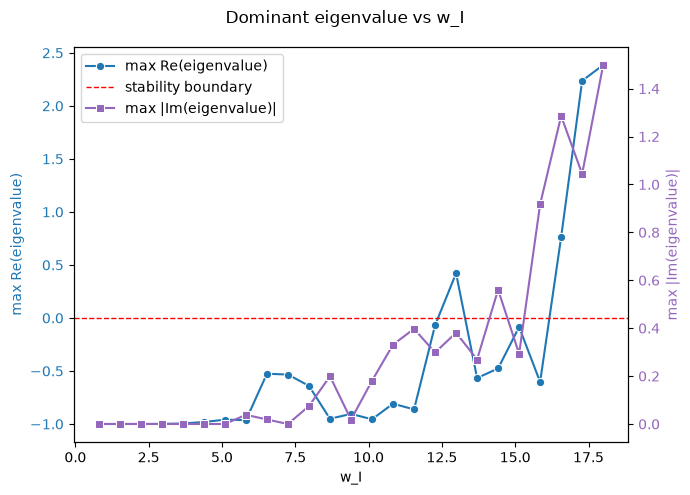

In [ ]:
import matplotlib.pyplot as plt
max_real_parts, max_complex_coeffs, all_fixed_points_clean, all_real_parts, all_complex_coeffs = zip(*wI_sweep_tracker)
max_real_parts = jnp.array(max_real_parts)
max_complex_coeffs = jnp.array(max_complex_coeffs)
all_real_parts = jnp.array(all_real_parts)
all_complex_coeffs = jnp.array(all_complex_coeffs)

scatter_x, scatter_real, scatter_imag = [], [], []
for wI, reals, imags in zip(wI_range, all_real_parts, all_complex_coeffs):
    for r, im in zip(reals, imags):
        scatter_x.append(float(wI))
        scatter_real.append(float(r))
        scatter_imag.append(float(im))
fig, ax1 = plt.subplots(figsize=(7, 5))

sns.lineplot(x=wI_range, y=max_real_parts, marker='o', color='tab:blue', ax=ax1, label='max Re(eigenvalue)')
ax1.scatter(scatter_x, scatter_real, color='tab:blue', alpha=0.3, s=25, label='all fixed points (Re)')

ax1.axhline(0, color='red', linestyle='--', linewidth=1, label='stability boundary')
ax1.set_xlabel('w_I')
ax1.set_ylabel('max Re(eigenvalue)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(x=wI_range, y=max_complex_coeffs, marker='s', color='tab:purple', ax=ax2, label='max |Im(eigenvalue)|')
ax2.scatter(scatter_x, scatter_imag, color='tab:purple', alpha=0.3, s=25, label='all fixed points (Im)')

ax2.set_ylabel('max |Im(eigenvalue)|', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')
ax2.grid(False)   # avoid double gridlines from the two overlapping axes

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax2.get_legend().remove()   # merged into ax1's legend above, so drop the duplicate

fig.suptitle('Dominant eigenvalue vs w_I')
fig.tight_layout()
plt.show()


In [ ]:
wE_sweep_tracker = []
i = 0

for wE in wE_range:
    print(f"starting {i}")
    exc_target = is_exc[:, None]
    exc_source = is_exc[None, :]

    magnitude = jnp.where(exc_source,
                        jnp.where(exc_target, wE, wE),
                        jnp.where(exc_target, w_EI, w_II))
    sign = jnp.where(exc_source, 1.0, -1.0)
    weight_matrix = magnitude * sign * jitter

    params = {
        "exc_map": is_exc,
        "2dmap": pos_init,
        "ext_input": I_ext,
        "distance_decay": a_dist,
        "sigmoid_steepness": a_sigmoid,
        "theta": theta,
        "weights": weight_matrix,
        "tau_I": tau_I,
        "tau_E": tau_E,
    }
    
    wE_sweep_tracker.append(get_local_behavior(params)[0:3])
    i+=1



starting 0
starting 1
starting 2
starting 3
starting 4
starting 5
starting 6
starting 7
starting 8
starting 9


[(Array(-0.7749936, dtype=float32), Array(0.00937313, dtype=float32)), (Array(0.36662698, dtype=float32), Array(0.09487119, dtype=float32)), (Array(-0.7013768, dtype=float32), Array(3.0124945e-06, dtype=float32)), (Array(-0.9683733, dtype=float32), Array(9.316165e-06, dtype=float32)), (Array(-0.9983599, dtype=float32), Array(0., dtype=float32)), (Array(-0.99991524, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999954, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999993, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999995, dtype=float32), Array(0., dtype=float32)), (Array(-0.9999997, dtype=float32), Array(5.3888383e-09, dtype=float32))]


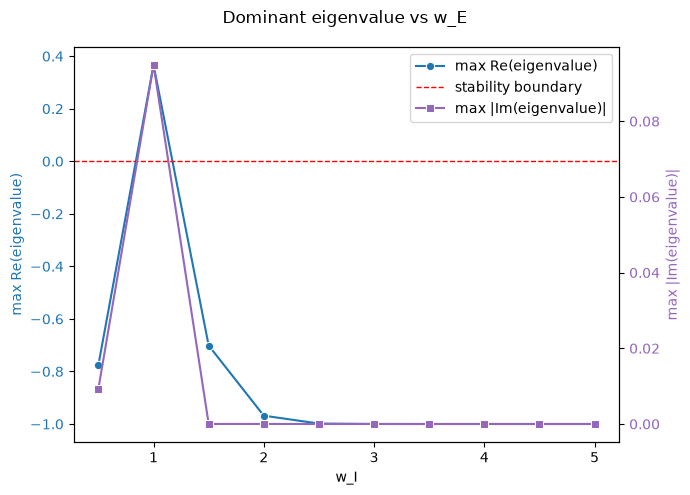

In [56]:

print(wE_sweep_tracker)

max_real_parts, max_complex_coeffs = zip(*wE_sweep_tracker)
max_real_parts = jnp.array(max_real_parts)
max_complex_coeffs = jnp.array(max_complex_coeffs)

fig, ax1 = plt.subplots(figsize=(7, 5))

sns.lineplot(x=wE_range, y=max_real_parts, marker='o', color='tab:blue', ax=ax1, label='max Re(eigenvalue)')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, label='stability boundary')
ax1.set_xlabel('w_I')
ax1.set_ylabel('max Re(eigenvalue)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(x=wE_range, y=max_complex_coeffs, marker='s', color='tab:purple', ax=ax2, label='max |Im(eigenvalue)|')
ax2.set_ylabel('max |Im(eigenvalue)|', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')
ax2.grid(False)   # avoid double gridlines from the two overlapping axes

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax2.get_legend().remove()   # merged into ax1's legend above, so drop the duplicate

fig.suptitle('Dominant eigenvalue vs w_E')
fig.tight_layout()
plt.show()

In [67]:
wExt_sweep_tracker = []
i = 0
# extI_range = jnp.linspace(0, 6, 5)    
# extE_range = jnp.linspace(0, 6, 5)

for extI in extI_range:
    for extE in extE_range:
        print(f"starting {i}")
        
        I_ext = jnp.concatenate([extE * jnp.ones(num_E), extI * jnp.ones(num_I)])
        magnitude = jnp.where(exc_source,
                    jnp.where(exc_target, w_EE, w_IE),
                    jnp.where(exc_target, w_EI, w_II))
        sign = jnp.where(exc_source, 1.0, -1.0)
        weight_matrix = magnitude * sign * jitter
        params = {
            "exc_map": is_exc,
            "2dmap": pos_init,
            "ext_input": I_ext,
            "distance_decay": a_dist,
            "sigmoid_steepness": a_sigmoid,
            "theta": theta,
            "weights": weight_matrix,
            "tau_I": tau_I,
            "tau_E": tau_E,
        }
        
        wExt_sweep_tracker.append(get_local_behavior(params)[0:3])
        i+=1



starting 0
starting 1
starting 2
starting 3
starting 4
starting 5
starting 6
starting 7
starting 8
starting 9
starting 10
starting 11
starting 12
starting 13
starting 14
starting 15
starting 16
starting 17
starting 18
starting 19
starting 20
starting 21
starting 22
starting 23
starting 24


[Array([0.10686658, 0.01435078, 0.01876936, 0.09317583, 0.04919897,
       0.01127429, 0.01241555, 0.31200755, 0.18420501, 0.26505044,
       0.01761713, 0.16637856, 0.2069474 , 0.10888492, 0.00862802,
       0.09212897, 0.01767552, 0.2406153 , 0.00891823, 0.00648583,
       0.33908933, 0.05190339, 0.04215989, 0.23850246, 0.2092714 ,
       0.00753328, 0.1060385 , 0.16070893, 0.09971652, 0.2442629 ,
       0.31889185, 0.02269472, 0.00874086, 0.02838344, 0.00805303,
       0.0097922 , 0.05299604, 0.27875534, 0.20339783, 0.2995026 ,
       0.00757173, 0.01234157, 0.00882166, 0.01388549, 0.00966682,
       0.0083727 , 0.20747355, 0.11277456, 0.00572627, 0.01075856],      dtype=float32), Array([0.98518485, 0.97836417, 0.9647598 , 0.98505366, 0.9803099 ,
       0.9787692 , 0.9765638 , 0.9852199 , 0.98522174, 0.9852208 ,
       0.9825908 , 0.9851953 , 0.9852234 , 0.9848598 , 0.9284465 ,
       0.98504245, 0.4608491 , 0.9852234 , 0.983622  , 0.42973453,
       0.9852249 , 0.9822344 , 0.984815

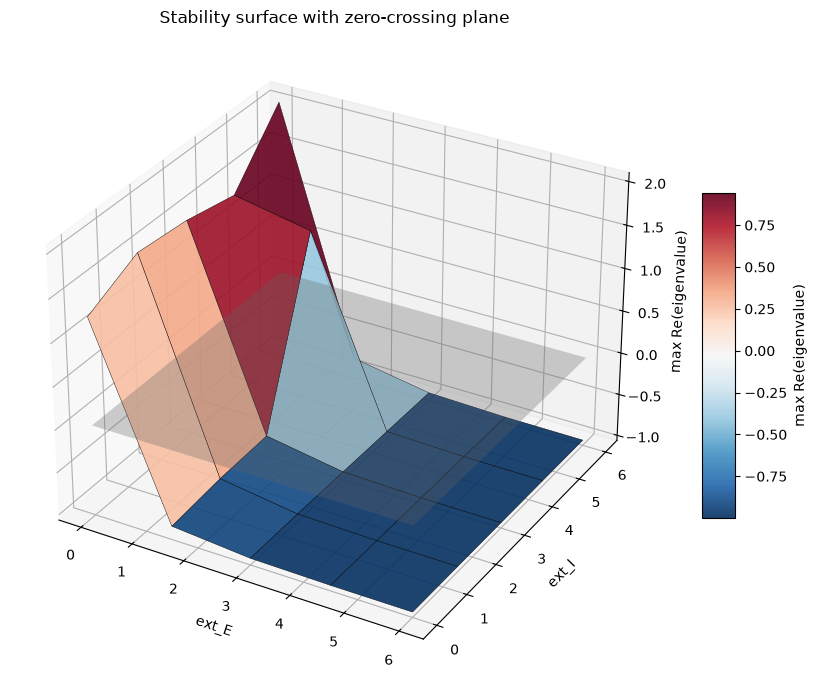

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# print(wExt_sweep_tracker)
max_real_parts, max_complex_coeffs, fixed_points_log = zip(*wExt_sweep_tracker) 
print(fixed_points_log[0])
print(fixed_points_log[24])
real_grid = jnp.array(max_real_parts).reshape(len(extI_range), len(extE_range))
imag_grid = jnp.array(max_complex_coeffs).reshape(len(extI_range), len(extE_range))
extE_grid, extI_grid = np.meshgrid(extE_range, extI_range)   # shape matches real_grid: (len(extI_range), len(extE_range))
real_grid_np = np.array(real_grid)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(extE_grid, extI_grid, real_grid_np, cmap='RdBu_r', edgecolor='k', linewidth=0.3, alpha=0.9)

zero_plane = np.zeros_like(real_grid_np)
ax.plot_surface(extE_grid, extI_grid, zero_plane, color='gray', alpha=0.3)

ax.set_xlabel('ext_E')
ax.set_ylabel('ext_I')
ax.set_zlabel('max Re(eigenvalue)')
ax.set_title('Stability surface with zero-crossing plane')
fig.colorbar(surf, shrink=0.5, aspect=10, label='max Re(eigenvalue)')
plt.tight_layout()
plt.show()

In [73]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Surface(x=extE_range, y=extI_range, z=real_grid_np, colorscale='RdBu', reversescale=True, opacity=0.9),
    go.Surface(x=extE_range, y=extI_range, z=np.zeros_like(real_grid_np), showscale=False, opacity=0.3, colorscale=[[0, 'gray'], [1, 'gray']])
])
fig.update_layout(scene=dict(xaxis_title='ext_E', yaxis_title='ext_I', zaxis_title='max Re(eigenvalue)'))
fig.show(renderer="browser")